# Diabetic Retinopathy Stage Classification
## DenseNet121 (Fundus) + DenseNet121 (OCT) + Fusion Layer + LightGBM Classifier
### Paired Data Augmentation | Patient-wise Split | SHAP Explainability

**DR Grading: 3-Class System**
- Class 0 : No DR
- Class 1 : NPDR (Non-Proliferative Diabetic Retinopathy)
- Class 2 : PDR  (Proliferative Diabetic Retinopathy)

**Pipeline:**
```
Fundus Image --> DenseNet121 (frozen) --> 1024-dim Feature Vector
                                                     |
                                            Fusion Layer (Concatenate)
                                            2048-dim Fused Vector
                                                     |
OCT Image    --> DenseNet121 (frozen) --> 1024-dim Feature Vector
                                                     |
                                           StandardScaler
                                                     |
                                        LightGBM Classifier
                                                     |
                                  DR Stage: No DR / NPDR / PDR
```

**Why DenseNet121 for both modalities?**
- DenseNet introduces dense connectivity: each layer receives input from ALL previous layers
- This improves feature reuse, gradient flow and reduces vanishing gradient problem
- Particularly effective for capturing hierarchical structural patterns in both Fundus and OCT
- Symmetric 2048-dim fused vector (1024 + 1024) enables fair modality comparison via SHAP
- Smaller fused vector (2048) vs EfficientNet variants (2560) — less risk of overfitting


## STEP 1 — Install Dependencies

In [ ]:
!pip install albumentations lightgbm shap --quiet
print('All dependencies installed')

All dependencies installed


## STEP 2 — Mount Google Drive & Import Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm
from PIL import Image
import io

import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from lightgbm import LGBMClassifier

import albumentations as A
import shap

print('All libraries imported successfully')
print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')

Mounted at /content/drive
All libraries imported successfully
TensorFlow version : 2.19.0
GPU available      : False


## STEP 3 — Configuration & Dataset Paths

In [ ]:
# ── Configuration ─────────────────────────────────────────────
IMG_SIZE      = 224
BATCH_SIZE    = 8
NUM_CLASSES   = 3      # No DR, NPDR, PDR
TEST_SIZE     = 0.2
RANDOM_STATE  = 42
NUM_AUGMENTS  = 4

# LightGBM hyperparameters
LGBM_ESTIMATORS = 500
LGBM_LR         = 0.05
LGBM_LEAVES     = 63

# ── Dataset Paths ──────────────────────────────────────────────
PROJECT_PATH  = "/content/drive/MyDrive/octdataset"
FUNDUS_FOLDER = "/content/drive/MyDrive/octdataset/eye fundus (2)/eye fundus"
OCT_FOLDER    = "/content/drive/MyDrive/octdataset/OCT/OCT_NEW"
FUNDUS_CSV    = "/content/drive/MyDrive/octdataset/EYE FUNDUS.csv"
OCT_CSV       = "/content/drive/MyDrive/octdataset/OCT.csv"

SAVE_DIR = '/content/drive/MyDrive/octdataset/saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── DR Stage Labels ────────────────────────────────────────────
STAGE_MAP = {
    0: 'No DR',
    1: 'NPDR',
    2: 'PDR'
}

os.chdir(PROJECT_PATH)
print('Configuration set')
print(f'  Image size           : {IMG_SIZE}x{IMG_SIZE}')
print(f'  Number of classes    : {NUM_CLASSES}  (No DR / NPDR / PDR)')
print(f'  Augments per sample  : {NUM_AUGMENTS}')
print(f'  Train/Test split     : {int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)}')
print(f'  Backbone (both)      : DenseNet121')
print(f'  Fused vector size    : 1024 + 1024 = 2048-dim')

Configuration set
  Image size           : 224x224
  Number of classes    : 3  (No DR / NPDR / PDR)
  Augments per sample  : 4
  Train/Test split     : 80/20
  Backbone (both)      : DenseNet121
  Fused vector size    : 1024 + 1024 = 2048-dim


## STEP 4 — Load CSVs & Inspect Labels

In [ ]:
fundus_df = pd.read_csv(FUNDUS_CSV)
oct_df    = pd.read_csv(OCT_CSV)

print('=== FUNDUS CSV ===')
print(fundus_df.head(5))
print(f'Columns          : {fundus_df.columns.tolist()}')
print(f'DR unique values : {fundus_df["DR"].unique()}')
print(f'DR value counts  :\n{fundus_df["DR"].value_counts()}')

print('\n=== OCT CSV ===')
print(oct_df.head(5))
print(f'Columns          : {oct_df.columns.tolist()}')
print(f'DR unique values : {oct_df["DR"].unique()}')
print(f'DR value counts  :\n{oct_df["DR"].value_counts()}')

=== FUNDUS CSV ===
          Name DME DR       Size
0  0736_OI_f_1   1  -  1000x1000
1  0100_OD_f_1   1  -  1000x1000
2  0101_OI_f_1   1  -  1000x1000
3  1029_OD_f_1   1  -  1000x1000
4  0102_OD_f_1   1  -  1000x1000
Columns          : ['Name', 'DME', 'DR', 'Size']
DR unique values : ['-' '0' 'NPDR' 'PDR' nan]
DR value counts  :
DR
0       1058
NPDR    1058
PDR     1055
-       1001
Name: count, dtype: int64

=== OCT CSV ===
          Name  DME DR
0  1222_OD_o_2    0  0
1  1222_OI_o_1    0  0
2  1223_OD_o_1    0  0
3  1223_OI_o_2    0  0
4  1224_OD_o_2    0  0
Columns          : ['Name', 'DME', 'DR']
DR unique values : ['0' 'NPDR' 'PDR' '-']
DR value counts  :
DR
-       4487
0        341
NPDR     119
PDR       53
Name: count, dtype: int64


## STEP 5 — Pair Fundus + OCT Images

In [ ]:
def extract_key(name):
    """
    Extract PatientID + Eye from filename.
    Example: '1333_OI_f_2.jpg' -> '1333_OI'
    This key links Fundus and OCT of the same patient and eye.
    """
    name  = str(name)
    parts = name.split('_')
    if len(parts) < 2:
        return None
    return parts[0] + '_' + parts[1]


def safe_label(v):
    """
    Convert DR label to integer class index.
    Matches actual CSV label format:
      '0'    -> 0  (No DR)
      'NPDR' -> 1  (Non-Proliferative DR)
      'PDR'  -> 2  (Proliferative DR)
      '-'    -> None (discarded)
    """
    if pd.isna(v):
        return None
    v = str(v).strip()
    if v in ['', '-', 'nan', 'None']:
        return None
    mapping = {
        '0'   : 0,
        'NPDR': 1,
        'PDR' : 2,
    }
    return mapping.get(v, None)


def find_path(folder, base):
    """Search for image file with multiple extension support."""
    for ext in ['.jpg', '.png', '.jpeg']:
        p = os.path.join(folder, base + ext)
        if os.path.exists(p):
            return p
    return None


# ── Build lookup maps ──────────────────────────────────────────
fundus_map = {}
for _, r in fundus_df.iterrows():
    key   = extract_key(r['Name'])
    label = safe_label(r['DR'])
    if key and label is not None:
        fundus_map[key] = (r['Name'], label)

oct_map = {}
for _, r in oct_df.iterrows():
    key   = extract_key(r['Name'])
    label = safe_label(r['DR'])
    if key and label is not None:
        oct_map[key] = (r['Name'], label)

print(f'Fundus entries with valid labels : {len(fundus_map)}')
print(f'OCT entries with valid labels    : {len(oct_map)}')

# ── Pair by patient key ────────────────────────────────────────
pairs = []
for key in set(fundus_map).intersection(oct_map):
    f_name, f_label = fundus_map[key]
    o_name, o_label = oct_map[key]
    if f_label != o_label:
        continue
    f_path = find_path(FUNDUS_FOLDER, f_name)
    o_path = find_path(OCT_FOLDER, o_name)
    if f_path and o_path:
        pairs.append((f_path, o_path, f_label, key))

print(f'\nTotal Paired Samples : {len(pairs)}')
print('\nPaired sample class distribution:')
for i, name in STAGE_MAP.items():
    count = sum(1 for _, _, label, _ in pairs if label == i)
    bar   = chr(9608) * count
    print(f'  {name:<8} (class {i}) : {count:>4}  {bar}')

Fundus entries with valid labels : 1971
OCT entries with valid labels    : 444

Total Paired Samples : 410

Paired sample class distribution:
  No DR    (class 0) :  294  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  NPDR     (class 1) :   69  █████████████████████████████████████████████████████████████████████
  PDR      (class 2) :   47  ███████████████████████████████████████████████


## STEP 6 — Load & Preprocess Images

In [ ]:
def load_image(path):
    """
    Load and preprocess image:
    - BGR to RGB
    - Resize to 224x224
    - Normalize to [0, 1]
    """
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype('float32') / 255.0
    return img


X_fundus    = []
X_oct       = []
y           = []
patient_ids = []

for f_path, o_path, label, pid in tqdm(pairs, desc='Loading images'):
    X_fundus.append(load_image(f_path))
    X_oct.append(load_image(o_path))
    y.append(label)
    patient_ids.append(pid)

X_fundus    = np.array(X_fundus)
X_oct       = np.array(X_oct)
y           = np.array(y)
patient_ids = np.array(patient_ids)

print(f'Images loaded successfully')
print(f'  Fundus array shape : {X_fundus.shape}')
print(f'  OCT array shape    : {X_oct.shape}')
print(f'  Labels shape       : {y.shape}')
print(f'  Unique patients    : {len(set(patient_ids))}')
print('\nClass distribution:')
for i, name in STAGE_MAP.items():
    print(f'  {name:<8} : {np.sum(y == i)}')

Loading images: 100%|██████████| 410/410 [11:35<00:00,  1.70s/it]


Images loaded successfully
  Fundus array shape : (410, 224, 224, 3)
  OCT array shape    : (410, 224, 224, 3)
  Labels shape       : (410,)
  Unique patients    : 410

Class distribution:
  No DR    : 294
  NPDR     : 69
  PDR      : 47


## STEP 7 — Patient-Wise Split (No Data Leakage)

In [ ]:
# GroupShuffleSplit ensures no patient appears in both
# train and test sets — completely preventing data leakage.

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

for train_idx, test_idx in gss.split(X_fundus, y, groups=patient_ids):
    Xf_train = X_fundus[train_idx]
    Xf_test  = X_fundus[test_idx]
    Xo_train = X_oct[train_idx]
    Xo_test  = X_oct[test_idx]
    y_train  = y[train_idx]
    y_test   = y[test_idx]

common = set(patient_ids[train_idx]).intersection(set(patient_ids[test_idx]))

print('Patient-wise split complete')
print(f'  Training samples : {len(Xf_train)}')
print(f'  Test samples     : {len(Xf_test)}')
print(f'  Common patients  : {len(common)}  <- must be 0 (no leakage)')

print('\nTrain class distribution:')
for i, name in STAGE_MAP.items():
    print(f'  {name:<8} : {np.sum(y_train == i)}')

print('\nTest class distribution:')
for i, name in STAGE_MAP.items():
    print(f'  {name:<8} : {np.sum(y_test == i)}')

Patient-wise split complete
  Training samples : 328
  Test samples     : 82
  Common patients  : 0  <- must be 0 (no leakage)

Train class distribution:
  No DR    : 234
  NPDR     : 57
  PDR      : 37

Test class distribution:
  No DR    : 60
  NPDR     : 12
  PDR      : 10


## STEP 8 — Paired Data Augmentation (Training Set Only)

In [ ]:
# ── Paired Augmentation Pipeline ──────────────────────────────
# Both Fundus and OCT images of a pair receive the EXACT SAME
# random transform using Albumentations 'additional_targets'.
# This preserves the clinical correspondence between modalities.

paired_augmentation = A.Compose(
    [
        # Geometric
        A.RandomRotate90(p=0.5),
        A.Rotate(limit=15, p=0.6),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),

        # Photometric — simulates different imaging device conditions
        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2,
            p=0.5
        ),

        # Noise — simulates retinal camera sensor noise
        A.GaussNoise(var_limit=(5.0, 25.0), p=0.3),

        # Blur — simulates slight focus or motion variation
        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 5), p=1.0),
            A.MotionBlur(blur_limit=3, p=1.0),
        ], p=0.2),

        A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    ],
    # CRITICAL: same random transform applied to OCT image too
    additional_targets={'oct_image': 'image'}
)


def augment_paired_dataset(Xf, Xo, y_labels, num_augments=4):
    """
    Apply paired augmentation to training set only.
    Both fundus and OCT of each pair get the exact same transform.
    """
    aug_fundus = list(Xf)
    aug_oct    = list(Xo)
    aug_labels = list(y_labels)

    for i in tqdm(range(len(Xf)), desc='Augmenting paired samples'):
        for _ in range(num_augments):
            f_uint8 = (Xf[i] * 255).astype(np.uint8)
            o_uint8 = (Xo[i] * 255).astype(np.uint8)

            result = paired_augmentation(
                image=f_uint8,
                oct_image=o_uint8
            )

            aug_fundus.append(result['image'].astype('float32') / 255.0)
            aug_oct.append(result['oct_image'].astype('float32') / 255.0)
            aug_labels.append(y_labels[i])

    return (
        np.array(aug_fundus),
        np.array(aug_oct),
        np.array(aug_labels)
    )


print(f'Augmenting training set ({NUM_AUGMENTS}x per sample)...')

Xf_train_aug, Xo_train_aug, y_train_aug = augment_paired_dataset(
    Xf_train, Xo_train, y_train,
    num_augments=NUM_AUGMENTS
)

print(f'\nAugmentation complete')
print(f'  Original train samples  : {len(Xf_train)}')
print(f'  Augmented train samples : {len(Xf_train_aug)}')
print(f'  Test samples (unchanged): {len(Xf_test)}')

print('\nAugmented train class distribution:')
for i, name in STAGE_MAP.items():
    print(f'  {name:<8} : {np.sum(y_train_aug == i)}')

Augmenting training set (4x per sample)...


Augmenting paired samples: 100%|██████████| 328/328 [00:06<00:00, 49.60it/s]



Augmentation complete
  Original train samples  : 328
  Augmented train samples : 1640
  Test samples (unchanged): 82

Augmented train class distribution:
  No DR    : 1170
  NPDR     : 285
  PDR      : 185


## STEP 9 — Visualize Paired Augmentation

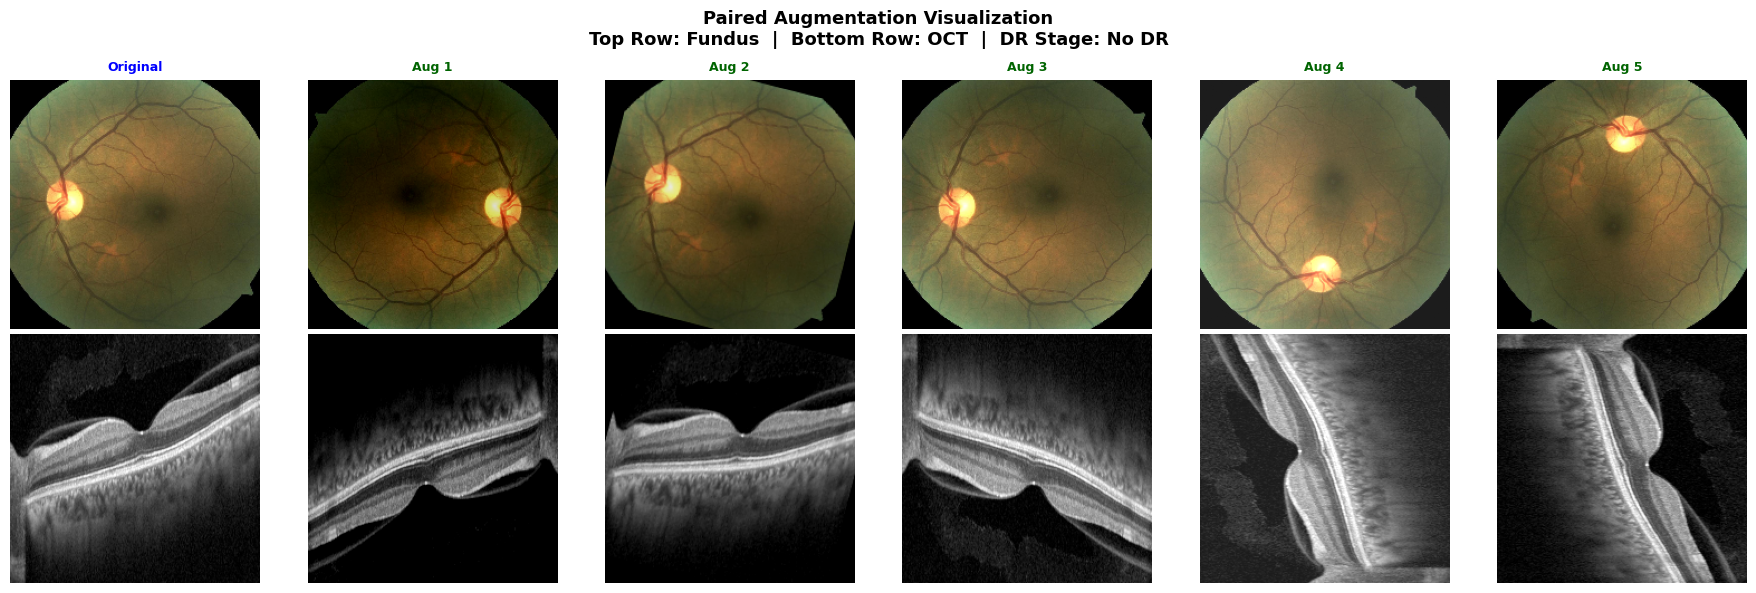

Augmentation visualization saved


In [ ]:
sample_idx = 0

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle(
    f'Paired Augmentation Visualization\n'
    f'Top Row: Fundus  |  Bottom Row: OCT  |  '
    f'DR Stage: {STAGE_MAP[y_train[sample_idx]]}',
    fontsize=13, fontweight='bold'
)

col_titles = ['Original', 'Aug 1', 'Aug 2', 'Aug 3', 'Aug 4', 'Aug 5']

for col_idx in range(6):
    if col_idx == 0:
        f_img = Xf_train[sample_idx]
        o_img = Xo_train[sample_idx]
        color = 'blue'
    else:
        f_uint8 = (Xf_train[sample_idx] * 255).astype(np.uint8)
        o_uint8 = (Xo_train[sample_idx] * 255).astype(np.uint8)
        result  = paired_augmentation(image=f_uint8, oct_image=o_uint8)
        f_img   = result['image'].astype('float32') / 255.0
        o_img   = result['oct_image'].astype('float32') / 255.0
        color   = 'darkgreen'

    axes[0, col_idx].imshow(np.clip(f_img, 0, 1))
    axes[0, col_idx].set_title(col_titles[col_idx], fontsize=9,
                                color=color, fontweight='bold')
    axes[0, col_idx].axis('off')
    axes[1, col_idx].imshow(np.clip(o_img, 0, 1))
    axes[1, col_idx].axis('off')

axes[0, 0].set_ylabel('Fundus', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('OCT', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/augmentation_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Augmentation visualization saved')

## STEP 10 — Build DenseNet121 Feature Extractors

In [ ]:
# ── Why DenseNet121 for BOTH modalities? ─────────────────────
#
# DenseNet (Densely Connected Convolutional Network) architecture:
#   - Each layer receives feature maps from ALL preceding layers
#   - This creates dense skip connections throughout the network
#
# Key advantages for retinal imaging:
#   - Improved feature reuse across all network depths
#   - Stronger gradient flow — reduces vanishing gradient problem
#   - Better representation of fine-grained retinal details
#   - More parameter-efficient than standard CNNs
#
# For Fundus images:
#   Dense connectivity captures multi-scale texture patterns
#   such as microaneurysms, hemorrhages, hard exudates
#   and vascular abnormalities at different resolutions.
#
# For OCT images:
#   Dense connectivity effectively captures hierarchical
#   structural features such as retinal layer boundaries,
#   fluid-filled regions and structural deformations.
#
# Using DenseNet121 for both:
#   - Symmetric 2048-dim fused vector (1024 + 1024)
#   - Smaller than EfficientNet variants — less overfitting risk
#   - Fair cross-modal comparison via SHAP
#   - Both instances are independent with separate weights

def build_densenet_extractor(name):
    """
    Build a frozen DenseNet121 feature extractor.
    Output: 1024-dimensional feature vector per image.
    """
    base = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False    # Frozen backbone — transfer learning
    x = GlobalAveragePooling2D()(base.output)
    return Model(base.input, x, name=name)


# Two separate DenseNet121 instances — independent weights
fundus_model = build_densenet_extractor('DenseNet121_Fundus')
oct_model    = build_densenet_extractor('DenseNet121_OCT')

fundus_dim = fundus_model.output_shape[-1]   # 1024
oct_dim    = oct_model.output_shape[-1]      # 1024

print('Feature extractor models built')
print(f'  DenseNet121 (Fundus) output : {fundus_dim}-dim')
print(f'  DenseNet121 (OCT) output    : {oct_dim}-dim')
print(f'  Fused vector size           : {fundus_dim + oct_dim}-dim  (after fusion)')
print(f'  Total trainable params      : 0  (both backbones frozen)')

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Feature extractor models built
  DenseNet121 (Fundus) output : 1024-dim
  DenseNet121 (OCT) output    : 1024-dim
  Fused vector size           : 2048-dim  (after fusion)
  Total trainable params      : 0  (both backbones frozen)


## STEP 11 — Extract Deep Features

In [ ]:
# Features extracted AFTER the patient-wise split
# Training uses augmented set | Test uses original set (never augmented)

print('Extracting Fundus features (DenseNet121)...')
fundus_train_feat = fundus_model.predict(Xf_train_aug, batch_size=BATCH_SIZE, verbose=1)
fundus_test_feat  = fundus_model.predict(Xf_test,      batch_size=BATCH_SIZE, verbose=1)

print('\nExtracting OCT features (DenseNet121)...')
oct_train_feat = oct_model.predict(Xo_train_aug, batch_size=BATCH_SIZE, verbose=1)
oct_test_feat  = oct_model.predict(Xo_test,      batch_size=BATCH_SIZE, verbose=1)

print(f'\nFeature extraction complete')
print(f'  Fundus train features : {fundus_train_feat.shape}')
print(f'  OCT train features    : {oct_train_feat.shape}')
print(f'  Fundus test features  : {fundus_test_feat.shape}')
print(f'  OCT test features     : {oct_test_feat.shape}')

Extracting Fundus features (DenseNet121)...
205/205 ━━━━━━━━━━━━━━━━━━━━ 275s 1s/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step

Extracting OCT features (DenseNet121)...
205/205 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step

Feature extraction complete
  Fundus train features : (1640, 1024)
  OCT train features    : (1640, 1024)
  Fundus test features  : (82, 1024)
  OCT test features     : (82, 1024)


## STEP 12 — Fusion Layer (Concatenation)

In [ ]:
# ── Fusion Layer ──────────────────────────────────────────────
#
# F = [Ff (1024) | Fo (1024)] = 2048-dimensional fused vector
#
# Since both branches use DenseNet121, the feature dimensions
# are perfectly symmetric. The 2048-dim fused vector contains:
#   First 1024 dims : Fundus texture + vascular features
#   Last  1024 dims : OCT structural + layered features
#
# DenseNet features encode hierarchical representations
# at multiple levels, making them highly complementary
# when fused from two different retinal modalities.

X_train = np.concatenate([fundus_train_feat, oct_train_feat], axis=1)
X_test  = np.concatenate([fundus_test_feat,  oct_test_feat],  axis=1)

print('Fusion layer applied')
print(f'  Fundus features (DenseNet121) : {fundus_train_feat.shape[1]} dims')
print(f'  OCT features    (DenseNet121) : {oct_train_feat.shape[1]} dims')
print(f'  Fused train                   : {X_train.shape}')
print(f'  Fused test                    : {X_test.shape}')
print(f'  Feature split point           : index {fundus_dim}')
print(f'    [0    : {fundus_dim}]  -> Fundus DenseNet121 features')
print(f'    [{fundus_dim} : {fundus_dim + oct_dim}] -> OCT DenseNet121 features')

Fusion layer applied
  Fundus features (DenseNet121) : 1024 dims
  OCT features    (DenseNet121) : 1024 dims
  Fused train                   : (1640, 2048)
  Fused test                    : (82, 2048)
  Feature split point           : index 1024
    [0    : 1024]  -> Fundus DenseNet121 features
    [1024 : 2048] -> OCT DenseNet121 features


## STEP 13 — Feature Scaling

In [ ]:
# StandardScaler: transforms to mean=0, std=1
# Fit ONLY on training data — transform both train and test.
# Never fit on test data to avoid data leakage.

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('Feature scaling complete')
print(f'  Train mean (approx) : {X_train.mean():.4f}  <- should be ~0')
print(f'  Train std  (approx) : {X_train.std():.4f}   <- should be ~1')
print(f'  Test scaled shape   : {X_test.shape}')

Feature scaling complete
  Train mean (approx) : -0.0000  <- should be ~0
  Train std  (approx) : 1.0000   <- should be ~1
  Test scaled shape   : (82, 2048)


## STEP 14 — Train LightGBM Classifier

In [ ]:
# ── LightGBM ───────────────────────────────────────────────────
# LightGBM (Light Gradient Boosting Machine) is chosen because:
#   - High accuracy on structured tabular feature data
#   - Fast training on small-to-medium datasets
#   - Strong nonlinear feature interaction learning
#   - Native SHAP support for explainability
#   - class_weight='balanced' handles class imbalance automatically
#
# DenseNet features are particularly well-suited for LightGBM
# because DenseNet's dense connectivity produces highly
# discriminative and compact feature representations.

lgbm = LGBMClassifier(
    n_estimators  = LGBM_ESTIMATORS,
    learning_rate = LGBM_LR,
    num_leaves    = LGBM_LEAVES,
    random_state  = RANDOM_STATE,
    class_weight  = 'balanced',
    verbose       = -1
)

print('Training LightGBM...')
print(f'  n_estimators  : {LGBM_ESTIMATORS}')
print(f'  learning_rate : {LGBM_LR}')
print(f'  num_leaves    : {LGBM_LEAVES}')
print(f'  class_weight  : balanced')
print(f'  Training on   : {X_train.shape[0]} samples, {X_train.shape[1]} features')

lgbm.fit(X_train, y_train_aug)

print('\nLightGBM training complete')

Training LightGBM...
  n_estimators  : 500
  learning_rate : 0.05
  num_leaves    : 63
  class_weight  : balanced
  Training on   : 1640 samples, 2048 features

LightGBM training complete


## STEP 15 — Evaluation & Metrics

In [ ]:
y_pred  = lgbm.predict(X_test)
y_proba = lgbm.predict_proba(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall    = recall_score(y_test, y_pred,    average='macro', zero_division=0)
f1        = f1_score(y_test, y_pred,        average='macro', zero_division=0)

print('=' * 60)
print('  DenseNet121 (Fundus) + DenseNet121 (OCT)')
print('  + Fusion Layer + LightGBM')
print('  3-Class DR Classification  (No DR / NPDR / PDR)')
print('=' * 60)
print(f'  Accuracy          : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  Precision (Macro) : {precision:.4f}')
print(f'  Recall    (Macro) : {recall:.4f}')
print(f'  F1 Score  (Macro) : {f1:.4f}')
print('=' * 60)

print('\nClassification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=list(STAGE_MAP.values()),
    zero_division=0
))

  DenseNet121 (Fundus) + DenseNet121 (OCT)
  + Fusion Layer + LightGBM
  3-Class DR Classification  (No DR / NPDR / PDR)
  Accuracy          : 0.8902  (89.02%)
  Precision (Macro) : 0.7506
  Recall    (Macro) : 0.7778
  F1 Score  (Macro) : 0.7632

Classification Report:
              precision    recall  f1-score   support

       No DR       1.00      0.97      0.98        60
        NPDR       0.62      0.67      0.64        12
         PDR       0.64      0.70      0.67        10

    accuracy                           0.89        82
   macro avg       0.75      0.78      0.76        82
weighted avg       0.90      0.89      0.89        82



## STEP 16 — Confusion Matrix

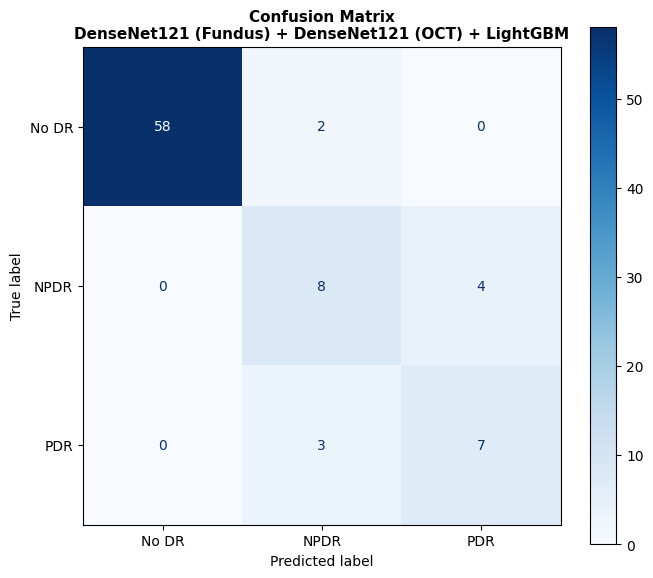

Confusion matrix saved


In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(STAGE_MAP.values())
)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(
    'Confusion Matrix\nDenseNet121 (Fundus) + DenseNet121 (OCT) + LightGBM',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/confusion_matrix_dense_dense_ml.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved')

## STEP 17 — SHAP Explainability

Computing SHAP values (may take a few minutes)...
SHAP values computed


<Figure size 1000x600 with 0 Axes>

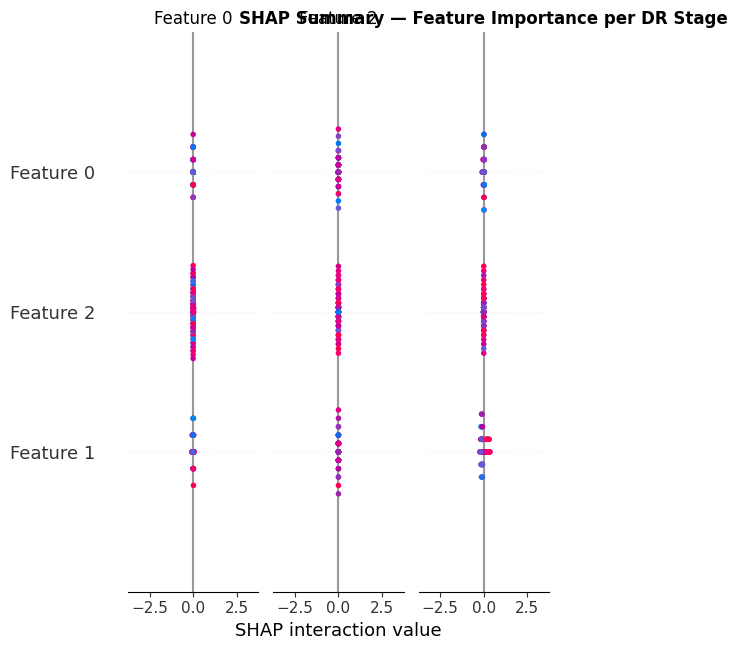

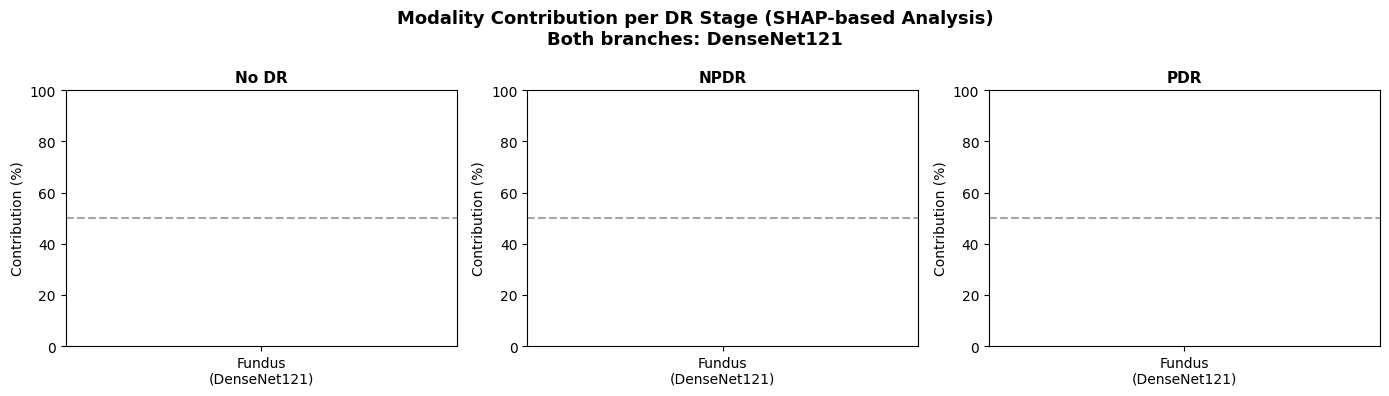

SHAP summary and modality contribution plots saved


In [ ]:
# ── SHAP Feature Importance ────────────────────────────────────
# Since both branches use the same DenseNet121 architecture,
# the 2048-dim fused vector is perfectly symmetric:
#   Features [0    : 1024] -> DenseNet121 (Fundus)
#   Features [1024 : 2048] -> DenseNet121 (OCT)
#
# DenseNet features represent multi-scale hierarchical patterns.
# SHAP reveals which hierarchy level and which modality
# contributes most to each DR stage prediction.

print('Computing SHAP values (may take a few minutes)...')

explainer   = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test)

print('SHAP values computed')

# ── Plot 1: SHAP Summary Plot ──────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test,
    class_names=list(STAGE_MAP.values()),
    show=False
)
plt.title('SHAP Summary — Feature Importance per DR Stage',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/shap_summary_dense_dense_ml.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Modality Contribution per DR Stage ─────────────────
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(14, 4))

for cls_idx in range(NUM_CLASSES):
    sv             = np.abs(shap_values[cls_idx])
    fundus_contrib = sv[:, :fundus_dim].mean()
    oct_contrib    = sv[:, fundus_dim:].mean()
    total          = fundus_contrib + oct_contrib

    f_pct = fundus_contrib / total * 100
    o_pct = oct_contrib    / total * 100

    axes[cls_idx].bar(
        ['Fundus\n(DenseNet121)', 'OCT\n(DenseNet121)'],
        [f_pct, o_pct],
        color=['#2196F3', '#FF5722'],
        edgecolor='white',
        width=0.5
    )
    axes[cls_idx].set_title(STAGE_MAP[cls_idx], fontsize=11, fontweight='bold')
    axes[cls_idx].set_ylabel('Contribution (%)')
    axes[cls_idx].set_ylim(0, 100)
    axes[cls_idx].axhline(50, color='gray', linestyle='--', alpha=0.7, label='Equal (50%)')
    axes[cls_idx].text(0, f_pct + 2, f'{f_pct:.1f}%', ha='center', fontsize=10, fontweight='bold')
    axes[cls_idx].text(1, o_pct + 2, f'{o_pct:.1f}%', ha='center', fontsize=10, fontweight='bold')

fig.suptitle(
    'Modality Contribution per DR Stage (SHAP-based Analysis)\n'
    'Both branches: DenseNet121',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/modality_contribution_dense_dense_ml.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP summary and modality contribution plots saved')

## STEP 18 — SHAP Waterfall Plot (Single Sample)

Generating waterfall plot for test sample 0
  True label      : No DR
  Predicted label : No DR


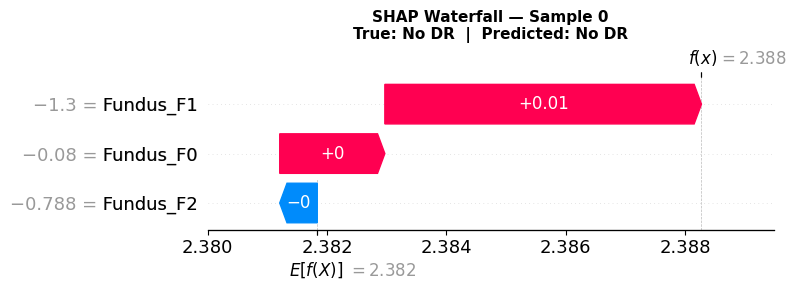

SHAP waterfall plot saved


In [ ]:
# Waterfall plot for a single test sample
# Shows how each feature pushes the prediction up or down
# from the base (expected) value

sample_idx = 0
pred_class = int(lgbm.predict(X_test[sample_idx:sample_idx+1])[0])

print(f'Generating waterfall plot for test sample {sample_idx}')
print(f'  True label      : {STAGE_MAP[y_test[sample_idx]]}')
print(f'  Predicted label : {STAGE_MAP[pred_class]}')

shap_exp = shap.Explanation(
    values          = shap_values[pred_class][sample_idx],
    base_values     = explainer.expected_value[pred_class],
    data            = X_test[sample_idx],
    feature_names   = (
        [f'Fundus_F{i}' for i in range(fundus_dim)] +
        [f'OCT_F{i}'    for i in range(oct_dim)]
    )
)

plt.figure(figsize=(12, 6))
shap.waterfall_plot(shap_exp, max_display=20, show=False)
plt.title(
    f'SHAP Waterfall — Sample {sample_idx}\n'
    f'True: {STAGE_MAP[y_test[sample_idx]]}  |  '
    f'Predicted: {STAGE_MAP[pred_class]}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/shap_waterfall_dense_dense_ml.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP waterfall plot saved')

## STEP 19 — Manual Upload Prediction

Step 1: Upload FUNDUS image


Saving 2000_OI_f_2.jpg to 2000_OI_f_2 (3).jpg

Step 2: Upload OCT image


Saving 2000_OI_o_1.jpg to 2000_OI_o_1 (3).jpg

         AI Diagnosis Result
  Predicted DR Stage : No DR
  Confidence         : 100.00%

  Per-Class Probabilities:
  No DR    : 100.00%  |||||||||||||||||||||||||||||  <-- Predicted
  NPDR     :  0.00%  
  PDR      :  0.00%  


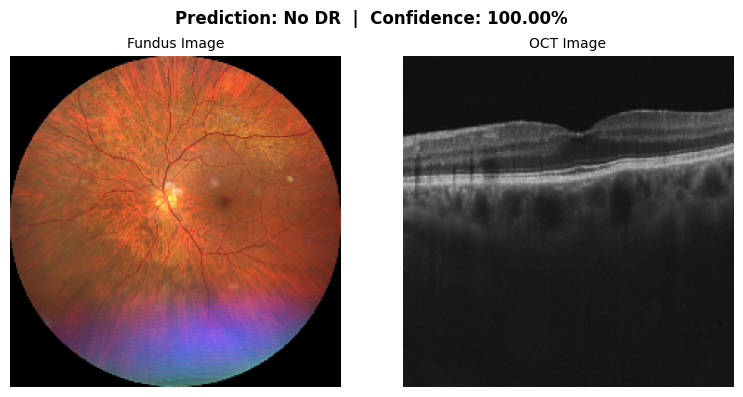

In [ ]:
from google.colab import files

def preprocess_uploaded(img_bytes):
    """Load uploaded image bytes and preprocess for model input."""
    img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
    img = np.array(img)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype('float32') / 255.0
    return np.expand_dims(img, axis=0)


def predict_manual_upload():
    """
    Upload a paired Fundus + OCT image and get DR stage prediction
    with confidence and per-class probabilities.
    """
    print('Step 1: Upload FUNDUS image')
    fundus_file = files.upload()

    print('\nStep 2: Upload OCT image')
    oct_file = files.upload()

    fundus_img = preprocess_uploaded(list(fundus_file.values())[0])
    oct_img    = preprocess_uploaded(list(oct_file.values())[0])

    # Feature extraction
    f_feat = fundus_model.predict(fundus_img, verbose=0)
    o_feat = oct_model.predict(oct_img, verbose=0)

    # Fusion + scaling
    fused = np.concatenate([f_feat, o_feat], axis=1)
    fused = scaler.transform(fused)

    # Prediction
    pred  = lgbm.predict(fused)[0]
    proba = lgbm.predict_proba(fused)[0]

    print('\n' + '=' * 45)
    print('         AI Diagnosis Result')
    print('=' * 45)
    print(f'  Predicted DR Stage : {STAGE_MAP[pred]}')
    print(f'  Confidence         : {np.max(proba)*100:.2f}%')
    print('\n  Per-Class Probabilities:')
    for i, (stage, prob) in enumerate(zip(STAGE_MAP.values(), proba)):
        marker = '  <-- Predicted' if i == pred else ''
        bar    = '|' * int(prob * 30)
        print(f'  {stage:<8} : {prob*100:5.2f}%  {bar}{marker}')
    print('=' * 45)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(
        f'Prediction: {STAGE_MAP[pred]}  |  Confidence: {np.max(proba)*100:.2f}%',
        fontsize=12, fontweight='bold'
    )
    axes[0].imshow(np.clip(fundus_img[0], 0, 1))
    axes[0].set_title('Fundus Image', fontsize=10)
    axes[0].axis('off')
    axes[1].imshow(np.clip(oct_img[0], 0, 1))
    axes[1].set_title('OCT Image', fontsize=10)
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()


predict_manual_upload()

## STEP 20 — Save Models

In [ ]:
import joblib

joblib.dump(lgbm,   f'{SAVE_DIR}/lgbm_dense_dense_ml.pkl')
joblib.dump(scaler, f'{SAVE_DIR}/scaler_dense_dense_ml.pkl')
fundus_model.save(f'{SAVE_DIR}/densenet121_fundus.h5')
oct_model.save(f'{SAVE_DIR}/densenet121_oct.h5')

print('All models saved to Google Drive')
print(f'  LightGBM             -> {SAVE_DIR}/lgbm_dense_dense_ml.pkl')
print(f'  Scaler               -> {SAVE_DIR}/scaler_dense_dense_ml.pkl')
print(f'  DenseNet121 Fundus   -> {SAVE_DIR}/densenet121_fundus.h5')
print(f'  DenseNet121 OCT      -> {SAVE_DIR}/densenet121_oct.h5')

All models saved to Google Drive
  LightGBM             -> /content/drive/MyDrive/octdataset/saved_models/lgbm_dense_dense_ml.pkl
  Scaler               -> /content/drive/MyDrive/octdataset/saved_models/scaler_dense_dense_ml.pkl
  DenseNet121 Fundus   -> /content/drive/MyDrive/octdataset/saved_models/densenet121_fundus.h5
  DenseNet121 OCT      -> /content/drive/MyDrive/octdataset/saved_models/densenet121_oct.h5


## STEP 21 — Final Summary

In [ ]:
print('=' * 60)
print('            FINAL EXPERIMENT SUMMARY')
print('=' * 60)
print('  Architecture')
print('    Fundus branch  : DenseNet121 (ImageNet pretrained)')
print('    OCT branch     : DenseNet121 (ImageNet pretrained)')
print('    Fusion layer   : Concatenation  (1024 + 1024 = 2048-dim)')
print('    Classifier     : LightGBM (class_weight=balanced)')
print('    Explainability : SHAP TreeExplainer')
print()
print('  Why DenseNet121 for both?')
print('    - Dense connectivity: each layer sees ALL previous layers')
print('    - Improved gradient flow and feature reuse')
print('    - Symmetric 2048-dim fused vector — fair SHAP comparison')
print('    - Compact features — lower overfitting risk vs EfficientNet')
print()
print('  DR Grading System')
print('    Class 0 : No DR  (No diabetic retinopathy)')
print('    Class 1 : NPDR   (Non-Proliferative DR)')
print('    Class 2 : PDR    (Proliferative DR)')
print()
print('  Dataset')
print(f'    Total paired samples    : {len(pairs)}')
print(f'    Train original          : {len(Xf_train)}')
print(f'    Train after aug (x{NUM_AUGMENTS})    : {len(Xf_train_aug)}')
print(f'    Test  (unchanged)       : {len(Xf_test)}')
print(f'    Split strategy          : Patient-wise GroupShuffleSplit')
print()
print('  Augmentation (same transform on both Fundus + OCT)')
print('    RandomRotate90, Rotate+-15, HorizontalFlip, VerticalFlip')
print('    BrightnessContrast, GaussNoise, GaussianBlur/MotionBlur')
print()
print('  Results')
print(f'    Accuracy          : {accuracy*100:.2f}%')
print(f'    Precision (Macro) : {precision:.4f}')
print(f'    Recall    (Macro) : {recall:.4f}')
print(f'    F1 Score  (Macro) : {f1:.4f}')
print('=' * 60)

            FINAL EXPERIMENT SUMMARY
  Architecture
    Fundus branch  : DenseNet121 (ImageNet pretrained)
    OCT branch     : DenseNet121 (ImageNet pretrained)
    Fusion layer   : Concatenation  (1024 + 1024 = 2048-dim)
    Classifier     : LightGBM (class_weight=balanced)
    Explainability : SHAP TreeExplainer

  Why DenseNet121 for both?
    - Dense connectivity: each layer sees ALL previous layers
    - Improved gradient flow and feature reuse
    - Symmetric 2048-dim fused vector — fair SHAP comparison
    - Compact features — lower overfitting risk vs EfficientNet

  DR Grading System
    Class 0 : No DR  (No diabetic retinopathy)
    Class 1 : NPDR   (Non-Proliferative DR)
    Class 2 : PDR    (Proliferative DR)

  Dataset
    Total paired samples    : 410
    Train original          : 328
    Train after aug (x4)    : 1640
    Test  (unchanged)       : 82
    Split strategy          : Patient-wise GroupShuffleSplit

  Augmentation (same transform on both Fundus + OCT)
    Ra